## Below is the code to recreate Figure 5.

Topic: Comparing HR Diagrams with brown dwarfs at different ages to show new `MergedPhillipsBaraffePisaEkstromParsec` evolutionary model.

In [1]:
# Importing necessary packages.
import numpy as np
import matplotlib.pyplot as plt
from spisea import synthetic, evolution, atmospheres, reddening, ifmr
from spisea.imf import imf, multiplicity

In [2]:
# Defining three different isochrones (logage = 6, 8, 10)
my_ifmr = ifmr.IFMR_Raithel18()
filt_list = ['wfc3,ir,f153m']

young_iso = synthetic.IsochronePhot(6, 0, 10,
                                    evo_model = evolution.MergedPhillipsBaraffePisaEkstromParsec(), 
                                    filters=filt_list)
med_iso = synthetic.IsochronePhot(8, 0, 10,
                                  evo_model = evolution.MergedPhillipsBaraffePisaEkstromParsec(), 
                                  filters=filt_list)
old_iso = synthetic.IsochronePhot(10, 0, 10,
                                  evo_model = evolution.MergedPhillipsBaraffePisaEkstromParsec(), 
                                  filters=filt_list)

In [3]:
# Defining our IMF with brown dwarfs
k_imf = imf.Salpeter_Kirkpatrick_2024()

# Defining clusters for all isochrones
cluster_mass = 10**6
young_cluster = synthetic.ResolvedCluster(young_iso, k_imf, cluster_mass, ifmr=my_ifmr)
med_cluster = synthetic.ResolvedCluster(med_iso, k_imf, cluster_mass, ifmr=my_ifmr)
old_cluster = synthetic.ResolvedCluster(old_iso, k_imf, cluster_mass, ifmr=my_ifmr)

# Get outputs
young_out = young_cluster.star_systems
med_out = med_cluster.star_systems
old_out = old_cluster.star_systems

/u/caitlinbegbie/.local/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


In [4]:
young_teff = young_out['Teff']
young_lum = young_out['L']
med_teff = med_out['Teff']
med_lum = med_out['L']
old_teff = old_out['Teff']
old_lum = old_out['L']

L_sun = 3.828 * 10**(26)

bd_idx_young = young_out['phase'] == 90.0
bd_idx_med = med_out['phase'] == 90.0
bd_idx_old = old_out['phase'] == 90.0

log_lum_young = np.log10(young_lum / L_sun)
log_teff_young = np.log10(young_teff)

log_lum_med = np.log10(med_lum / L_sun)
log_teff_med = np.log10(med_teff)

log_lum_old = np.log10(old_lum / L_sun)
log_teff_old = np.log10(old_teff)

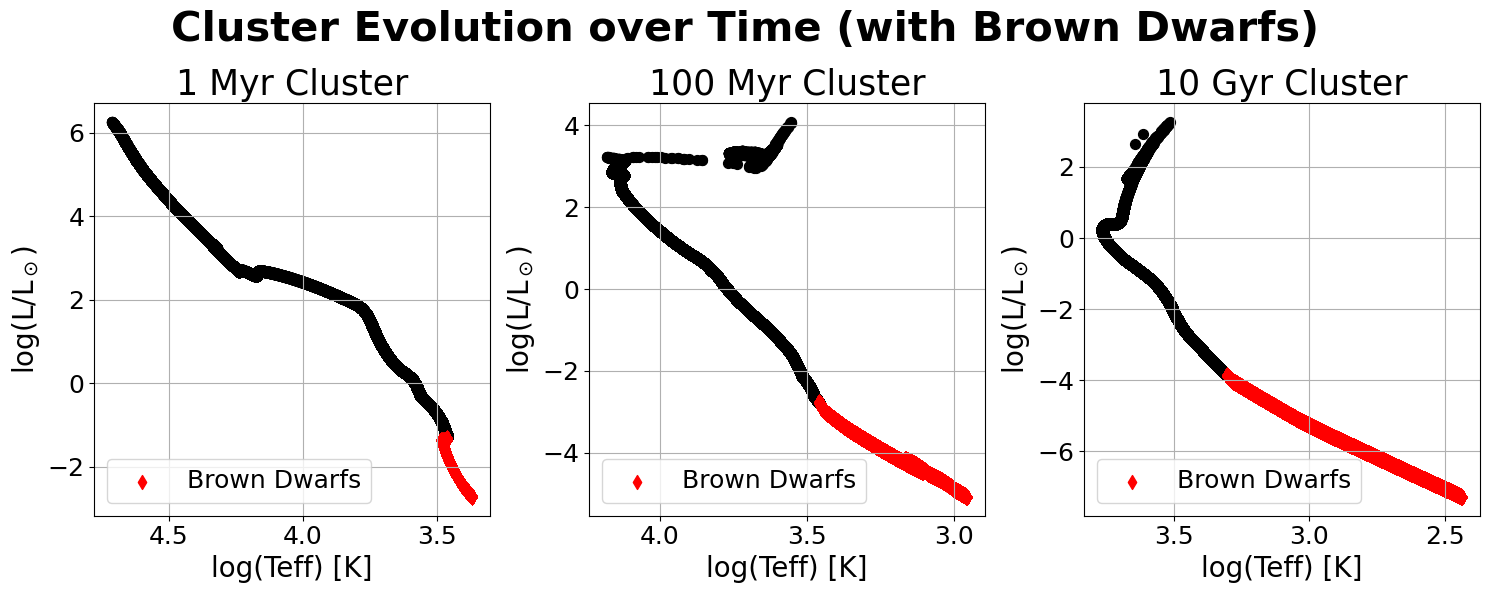

In [5]:
# Plotting CMDs
fig, axs = plt.subplots(1, 3, figsize=(15,6))

plt.suptitle('Cluster Evolution over Time (with Brown Dwarfs)', fontsize=30, fontweight='bold')

axs[0].scatter(log_teff_young[~bd_idx_young], log_lum_young[~bd_idx_young], s=50, color='black')
axs[0].scatter(log_teff_young[bd_idx_young], log_lum_young[bd_idx_young], marker='d', s=50, color='red', label='Brown Dwarfs')
axs[0].invert_xaxis()
axs[0].set_title('1 Myr Cluster', fontsize=25)
axs[0].set_xlabel('log(Teff) [K]', fontsize=20)
axs[0].set_ylabel('log(L/L$_\odot$)', fontsize=20)
axs[0].tick_params(axis='both', labelsize=18)
axs[0].legend(loc='lower left', fontsize=18)
axs[0].grid()

axs[1].scatter(log_teff_med[~bd_idx_med], log_lum_med[~bd_idx_med], s=50, color='black')
axs[1].scatter(log_teff_med[bd_idx_med], log_lum_med[bd_idx_med], marker='d', s=50, color='red', label='Brown Dwarfs')
axs[1].invert_xaxis()
axs[1].set_title('100 Myr Cluster', fontsize=25)
axs[1].set_xlabel('log(Teff) [K]', fontsize=20)
axs[1].set_ylabel('log(L/L$_\odot$)', fontsize=20)
axs[1].tick_params(axis='both', labelsize=18)
axs[1].legend(loc='lower left', fontsize=18)
axs[1].grid()

axs[2].scatter(log_teff_old[~bd_idx_old], log_lum_old[~bd_idx_old], s=50, color='black')
axs[2].scatter(log_teff_old[bd_idx_old], log_lum_old[bd_idx_old], marker='d', s=50, color='red', label='Brown Dwarfs')
axs[2].invert_xaxis()
axs[2].set_title('10 Gyr Cluster', fontsize=25)
axs[2].set_xlabel('log(Teff) [K]', fontsize=20)
axs[2].set_ylabel('log(L/L$_\odot$)', fontsize=20)
axs[2].tick_params(axis='both', labelsize=18)
axs[2].legend(loc='lower left', fontsize=18)
axs[2].grid()

plt.tight_layout()
#plt.savefig('cmds.png')
plt.show()